In [9]:
import keras
import tensorflow as tf

# Load dataset
dataset_train = r'D:/Amr/Portfolio/All time project/ready to publish/DL/Project 3/dataset/train'
dataset_val = r'D:/Amr/Portfolio/All time project/ready to publish/DL/Project 3/dataset/val'
dataset_test = r'D:/Amr/Portfolio/All time project/ready to publish/DL/Project 3/dataset/test'

SEED = 42
IMG_SIZE = (224, 224)

train_ds = keras.utils.image_dataset_from_directory(
    dataset_train,
    image_size=IMG_SIZE,
    seed=SEED,
    pad_to_aspect_ratio=True,
    shuffle=True,
)

val_ds = keras.utils.image_dataset_from_directory(
    dataset_val,
    image_size=IMG_SIZE,
    seed=SEED,
    pad_to_aspect_ratio=True,
    shuffle=True,
)

test_ds = keras.utils.image_dataset_from_directory(
    dataset_test,
    image_size=IMG_SIZE,
    seed=SEED,
    pad_to_aspect_ratio=True,
    shuffle=True,
)

class_names = train_ds.class_names
print(class_names)

Found 55 files belonging to 2 classes.
Found 15 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
['fresh apple', 'rotten apple']


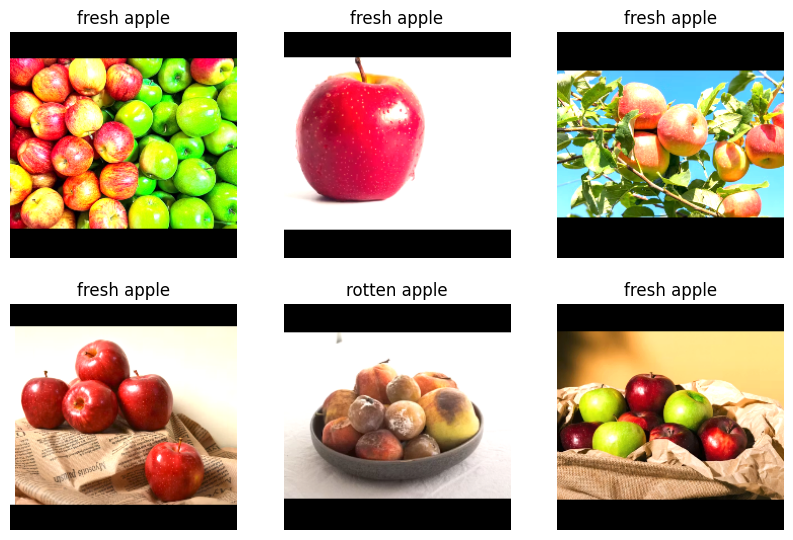

In [10]:
import matplotlib.pyplot as plt

# Visualize
images, labels = next(iter(train_ds))
plt.figure(figsize=(10,10))
for i in range(6):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.show()

In [11]:
# Normalize

train_ds = train_ds.map(lambda image, label: (image / 255.0, label))
val_ds = val_ds.map(lambda image, label: (image / 255.0, label))
test_ds = test_ds.map(lambda image, label: (image / 255.0, label))

# Checking result
for images, labels in train_ds.take(1):
    print(images.shape)

(32, 224, 224, 3)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 274ms/step - accuracy: 0.5091 - loss: 1.9623 - val_accuracy: 0.4667 - val_loss: 1.3262
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.5091 - loss: 1.1583 - val_accuracy: 0.6000 - val_loss: 0.6231
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.6545 - loss: 0.6271 - val_accuracy: 0.7333 - val_loss: 0.6071
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 381ms/step - accuracy: 0.7273 - loss: 0.5507 - val_accuracy: 0.7333 - val_loss: 0.5031
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 371ms/step - accuracy: 0.8545 - loss: 0.3962 - val_accuracy: 0.7333 - val_loss: 0.5697
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 373ms/step - accuracy: 0.7636 - loss: 0.4331 - val_accuracy: 0.7333 - val_loss: 0.4538
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 373ms/step - accuracy: 0.9455 - loss: 0.2993 - val_accuracy: 0.7333 - val_loss: 0.5017
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 375ms/step - accuracy: 0.9455 - loss: 0.2455 - val_accuracy: 0.9333 - val_loss:

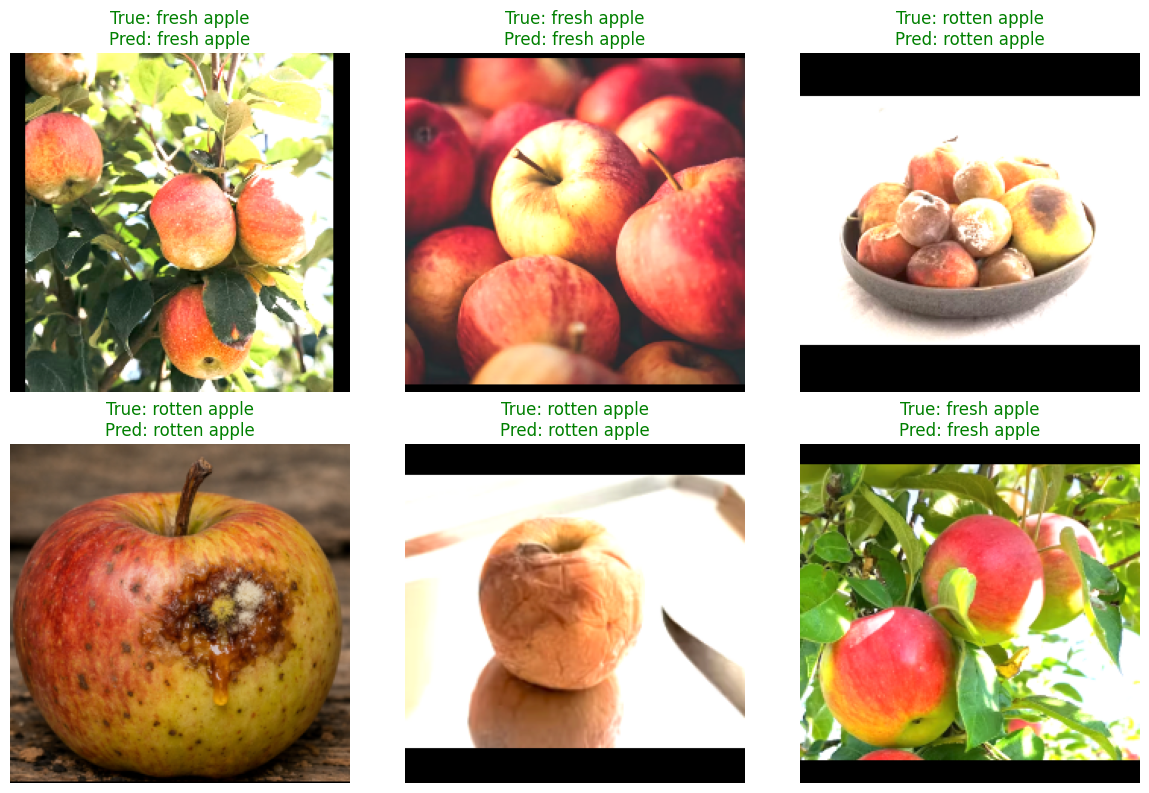

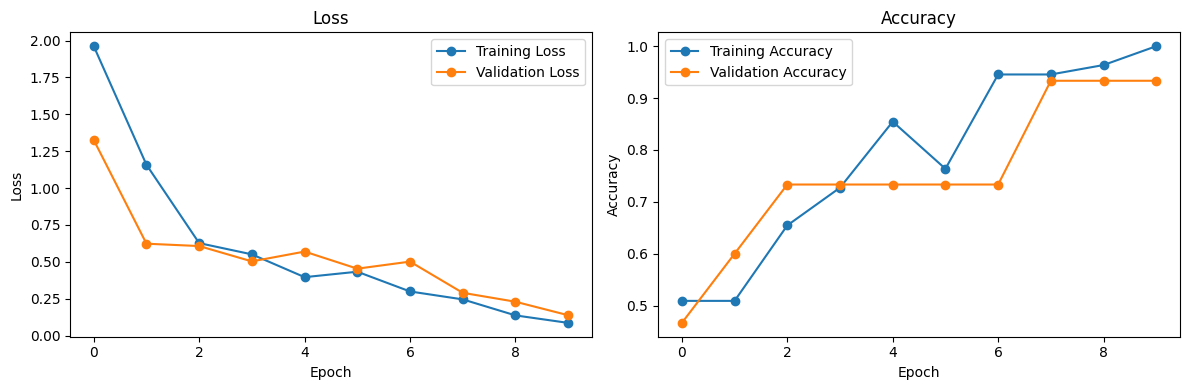

In [12]:
from keras import Sequential, layers
import matplotlib.pyplot as plt

# Modelling
model = Sequential([
    layers.Conv2D(32, kernel_size=3, activation='relu', input_shape=[224,224,3]),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(64, kernel_size=3, activation='relu'),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(128, kernel_size=3, activation='relu'),
    layers.MaxPooling2D(pool_size=2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

model.compile(
    loss='binary_crossentropy',
    optimizer='nadam',
    metrics=['accuracy']
)

history = model.fit(train_ds, epochs=10, validation_data=val_ds)

# Evaluate
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

sample_images, sample_labels = next(iter(test_ds))
prediction = model.predict(sample_images)
predicted = (prediction > 0.5).astype(int).flatten()

# Visualize prediction
plt.figure(figsize=(12, 8))
n_show = min(6, len(sample_images))
for i in range(n_show):
    plt.subplot(2, 3, i + 1)
    plt.imshow(sample_images[i].numpy()) 
    true_label = class_names[int(sample_labels[i])]
    pred_label = class_names[predicted[i]]
    color = "green" if true_label == pred_label else "red"
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.axis("off")
plt.tight_layout()
plt.show()

# Visualize training
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], marker='o', label='Training Loss')
plt.plot(history.history['val_loss'], marker='o', label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()